In [1]:
pip install transformers pdf2image pillow


In [2]:
from transformers import TableTransformerForObjectDetection, DetrImageProcessor
from pdf2image import convert_from_path
from PIL import Image
import torch

# Load model and processor
model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-detection")
processor = DetrImageProcessor.from_pretrained("microsoft/table-transformer-detection")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Some weights of the model checkpoint at microsoft/table-transformer-detection were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [4]:
!apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 186 kB of archives.
After this operation, 696 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.5 [186 kB]
Fetched 186 kB in 1s (248 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 123623 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.5_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.5) ...
Setting up poppler-utils (22.02.0-2ubuntu0.5) ...
Processing triggers for man-db (2.10.2-1) ...


In [10]:
# Convert PDF to images
pdf_path = '/content/nutrients-10-00671 processed beans.pdf'
images = convert_from_path(pdf_path, dpi=300)  # Higher DPI can improve table extraction accuracy


In [11]:
tables = []

for img in images:
    # Preprocess image
    pixel_values = processor(images=img, return_tensors="pt").pixel_values

    # Run the model
    outputs = model(pixel_values=pixel_values)

    # Extract boxes and labels for detected tables
    boxes = outputs.logits.argmax(-1)  # get the predicted class labels
    boxes = processor.post_process_object_detection(outputs, target_sizes=[img.size])[0]["boxes"]

    # Store results
    tables.append({
        "image": img,
        "boxes": boxes
    })


In [12]:
tables

[{'image': <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=2481x3508>,
  'boxes': tensor([[ 649.8437,  688.4204, 3044.1533,  997.4716]],
         grad_fn=<IndexBackward0>)},
 {'image': <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=2481x3508>,
  'boxes': tensor([[ 598.0270, 2213.9536, 2931.9814, 2377.1289]],
         grad_fn=<IndexBackward0>)},
 {'image': <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=2481x3508>,
  'boxes': tensor([[ 584.0635, 2110.8613, 3001.2822, 2289.5979]],
         grad_fn=<IndexBackward0>)},
 {'image': <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=2481x3508>,
  'boxes': tensor([], size=(0, 4), grad_fn=<IndexBackward0>)},
 {'image': <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=2481x3508>,
  'boxes': tensor([[1296.1846,  725.3680, 2186.6777, 1548.6625]],
         grad_fn=<IndexBackward0>)},
 {'image': <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=2481x3508>,
  'boxes': tensor([[ 653.4297, 2217.9443, 2903.7310, 2381.1331]],
   

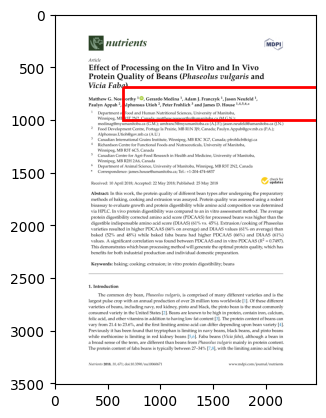

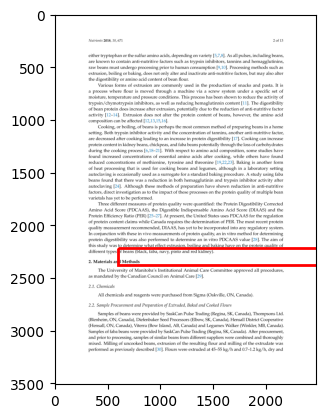

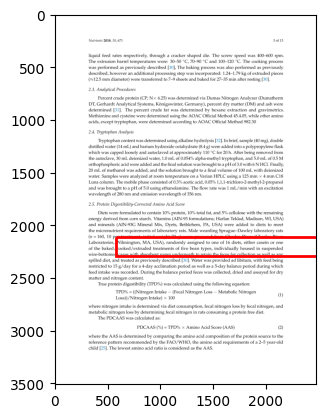

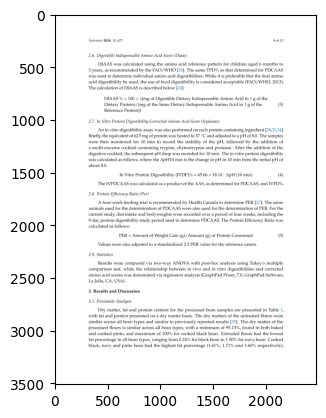

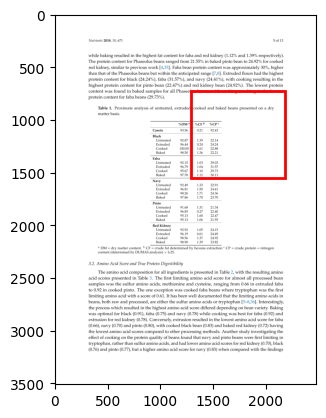

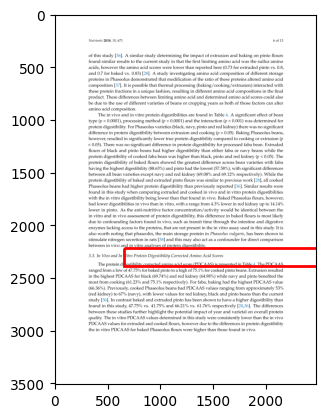

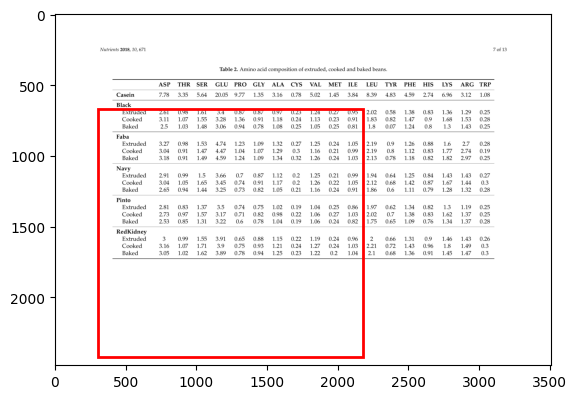

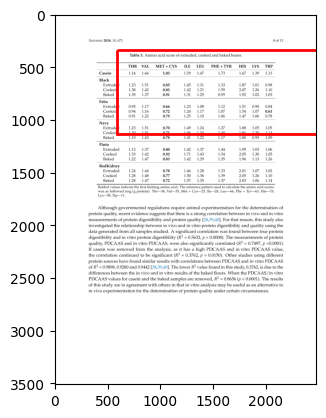

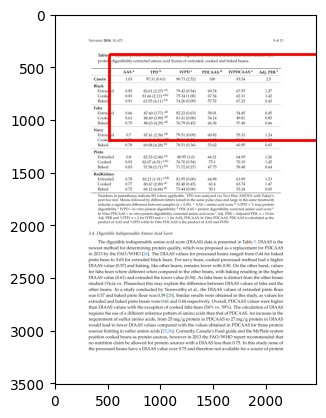

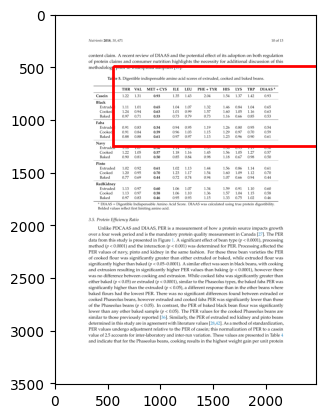

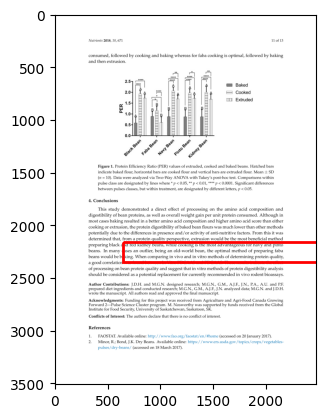

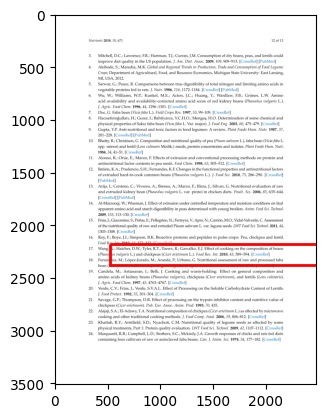

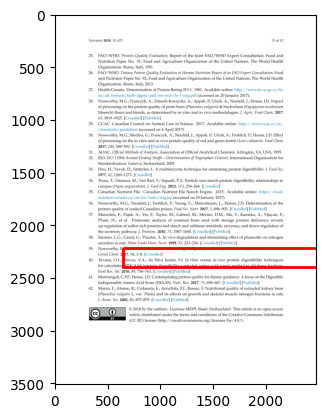

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

for page in tables:
    # Display the image
    fig, ax = plt.subplots(1)
    ax.imshow(page["image"])

    # Draw bounding boxes for each detected table
    for box in page["boxes"]:
        # Get box coordinates
        xmin, ymin, xmax, ymax = box.tolist()

        # Create a rectangle patch
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )

        # Add the rectangle to the plot
        ax.add_patch(rect)

    plt.show()


In [9]:
for idx, page in enumerate(tables):
    for i, box in enumerate(page["boxes"]):
        # Convert box coordinates to integer values using .item() for single-element tensors or .tolist() for multi-element tensors
        cropped_image = page["image"].crop((
            int(box[0].item()),
            int(box[1].item()),
            int(box[2].item()),
            int(box[3].item())
        ))
        cropped_image.save(f"table_page_{idx+1}_table_{i+1}.png")